In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import pickle


In [2]:
data=pd.read_csv('Rainfall.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [4]:
## Removing the extra spaces from all the columns 

data.columns=data.columns.str.strip()

In [5]:
data=data.drop(columns=['day'])

In [6]:
## Checking the number of missing values

data['winddirection']=data['winddirection'].fillna(data['winddirection'].mode()[0])
data['windspeed']=data['windspeed'].fillna(data['windspeed'].median())

In [7]:
## Converting all the Yes and No into 1 and 0 respectively

data['rainfall']=data['rainfall'].map({'yes': 1 ,'no':0})

In [8]:
## setting all plots to white grid
sns.set(style='whitegrid')

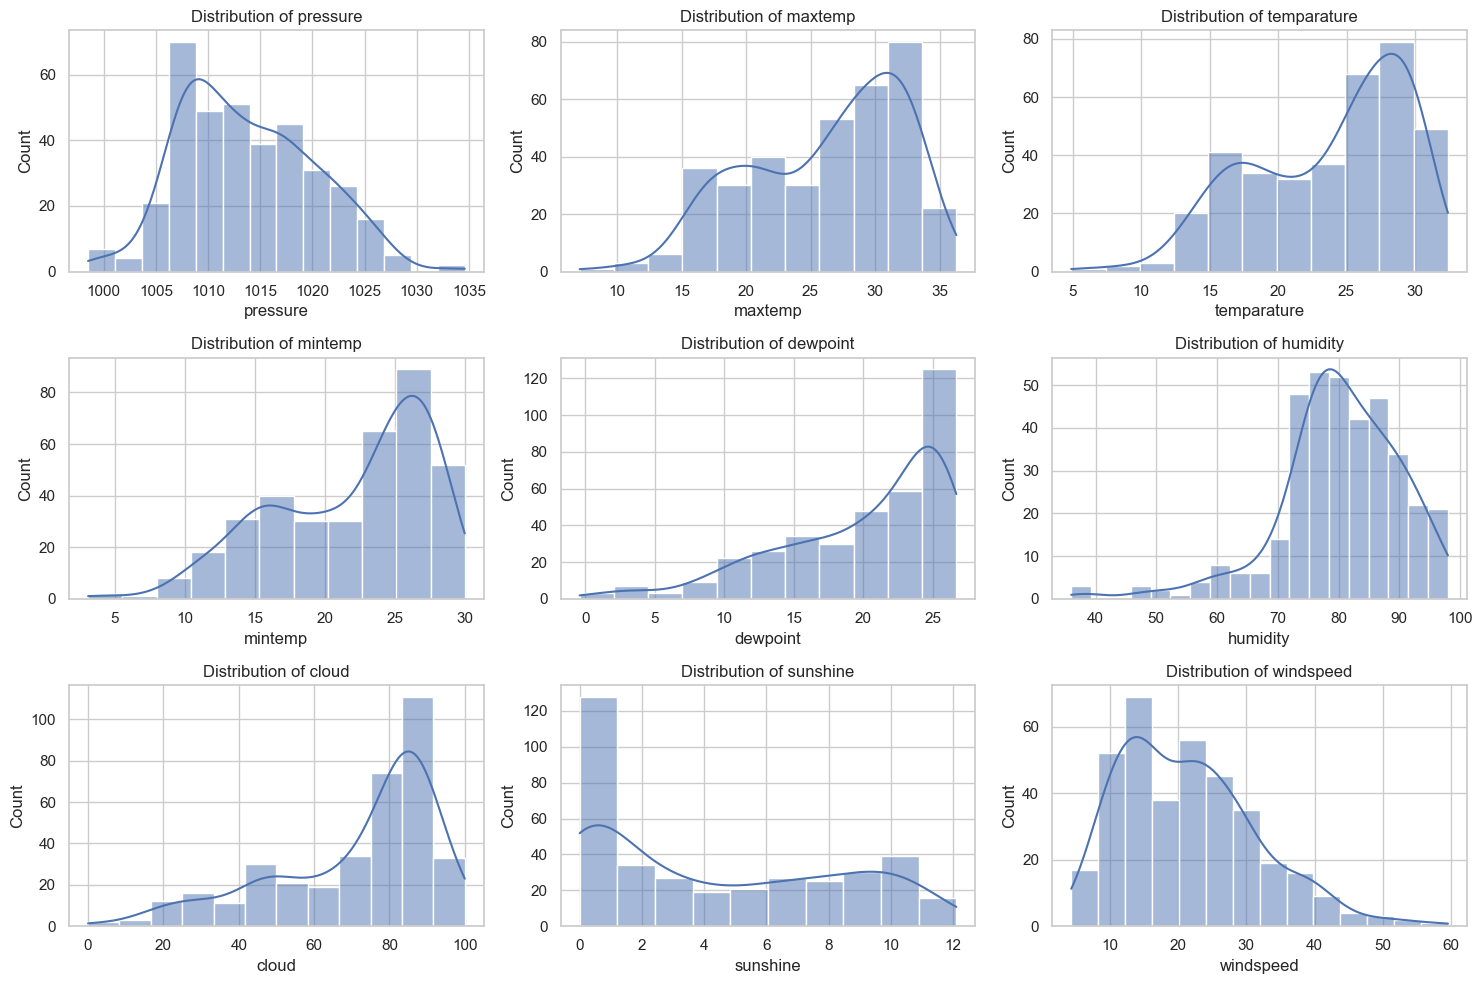

In [9]:
plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure','maxtemp','temparature','mintemp','dewpoint','humidity','cloud','sunshine','windspeed'],1):
    plt.subplot(3,3,i)
    sns.histplot(data[column],kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()


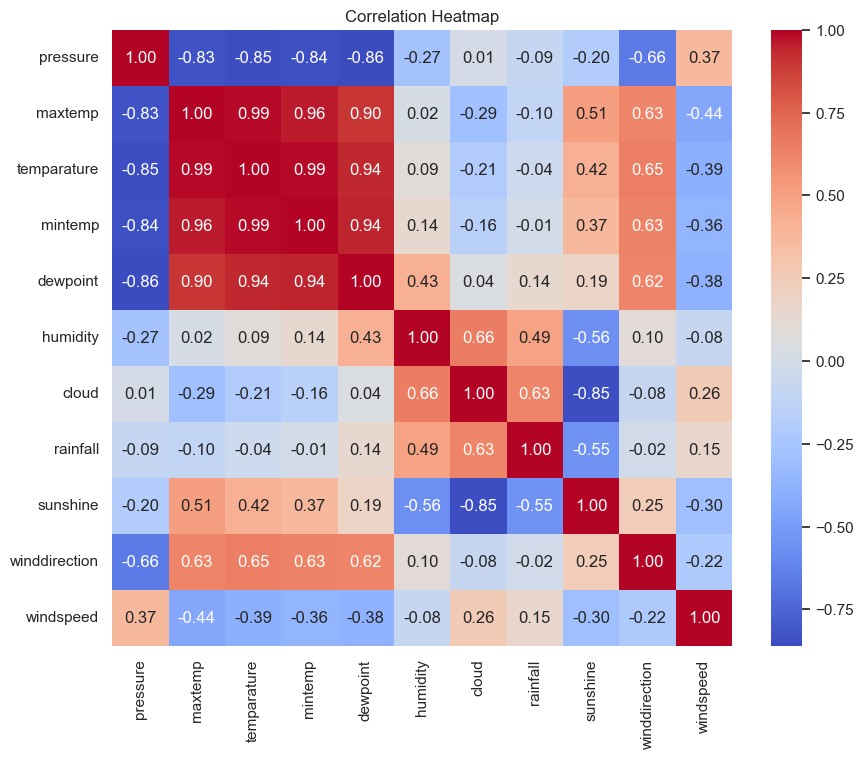

In [10]:
## making a correlation matrix heatmap

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

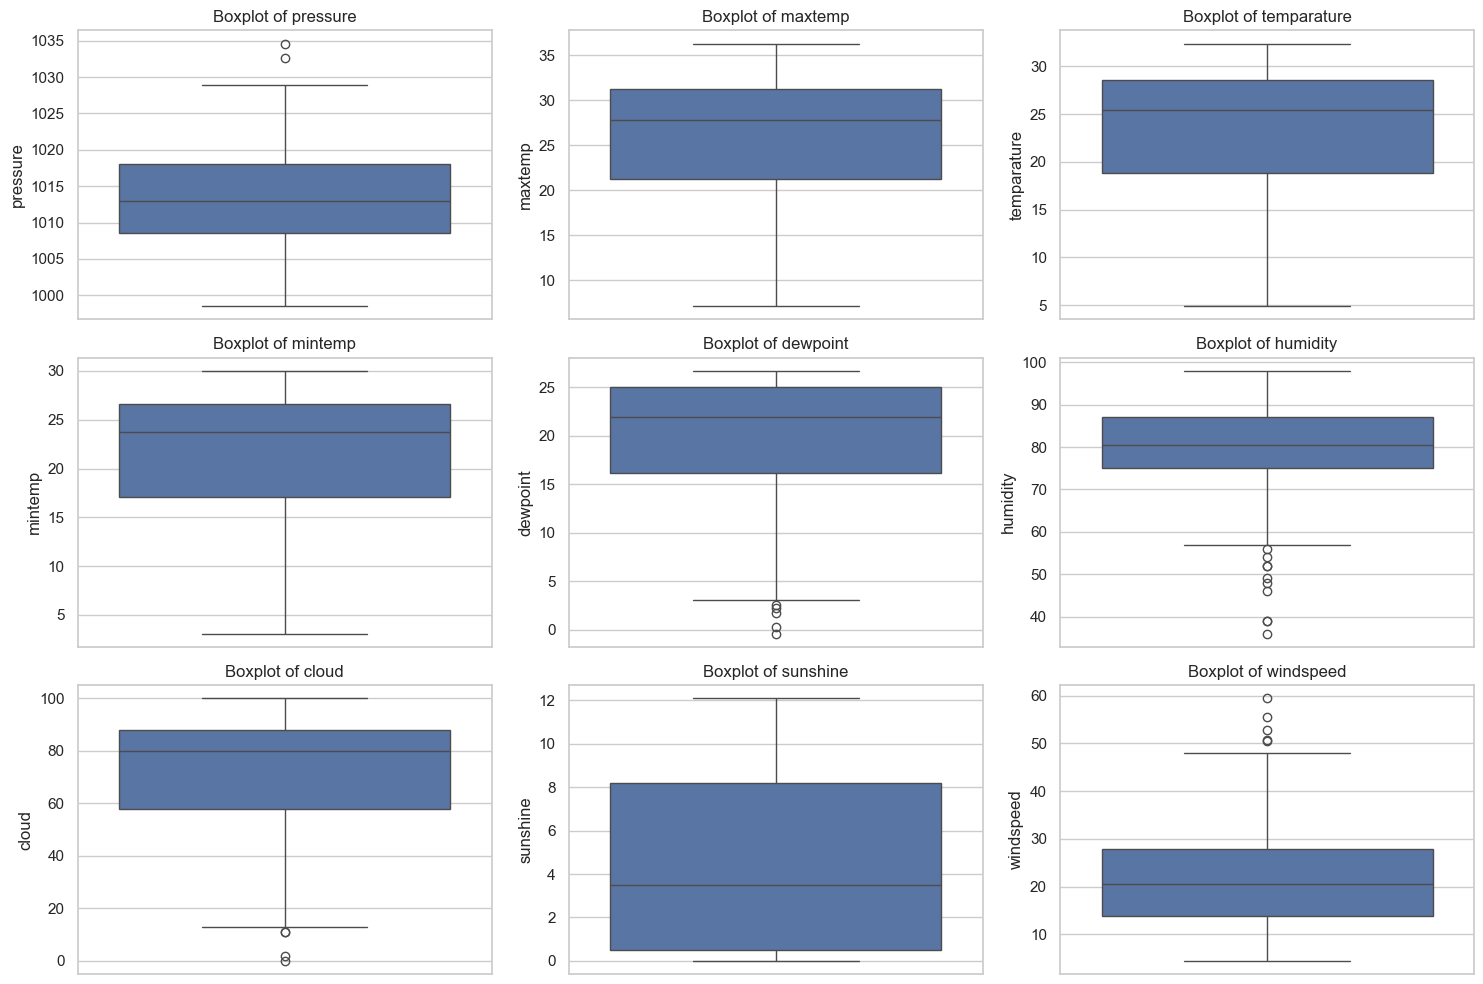

In [11]:
plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure','maxtemp','temparature','mintemp','dewpoint','humidity','cloud','sunshine','windspeed'],1):
    plt.subplot(3,3,i)
    sns.boxplot(data[column])
    plt.title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

In [12]:
## Dropping highly correllated columns

data=data.drop(columns=['maxtemp','temparature','mintemp'])

In [13]:
## Seprating majority and minority class 

df_majority= data[data['rainfall']== 1]
df_minority= data[data['rainfall']== 0]


In [14]:
## Downsampling majority class to match minority count

df_majority_downsampled= resample(df_majority, replace= False, n_samples=len(df_minority), random_state=42)

In [15]:
df_downsampled=pd.concat([df_majority_downsampled,df_minority])

In [16]:
## Shuffling the final dataframe

df_downsampled=df_downsampled.sample(frac=1,random_state=42).reset_index(drop=True)

In [17]:
## Splitting the features and target into X and y

X=df_downsampled.drop(columns=['rainfall'])
y=df_downsampled['rainfall']

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

## Model Training

In [19]:
rf_model=RandomForestClassifier(random_state=42)

param_grid_rf={'n_estimators':[50,100,200],
               'max_features':['sqrt','log2'],
               'max_depth':[None,10,20,30],
               'min_samples_split':[2,5,10],
               'min_samples_leaf':[1,2,4]
              }

In [20]:
## Hypertuning using GridSearchCV
grid_search_rf=GridSearchCV(estimator=rf_model,param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

grid_search_rf.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [21]:
best_rf_model=grid_search_rf.best_estimator_

print('Best models for Random Forest: ',grid_search_rf.best_params_)

Best models for Random Forest:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


## Model Evaluation

In [22]:
cv_score = cross_val_score(best_rf_model,X_train,y_train,cv=5)
print('Cross Validation Score:',cv_score)
print("Mean Cross Validation Score: ",np.mean(cv_score))

Cross Validation Score: [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892]
Mean Cross Validation Score:  0.818918918918919


In [23]:
y_pred= best_rf_model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test,y_pred))
print("Test Confusion Matrix :\n",confusion_matrix(y_test,y_pred))
print("Classification Report :", classification_report(y_test,y_pred))
      

Test Accuracy : 0.7446808510638298
Test Confusion Matrix :
 [[17  7]
 [ 5 18]]
Classification Report :               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



In [24]:
X_train.columns

Index(['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [42]:
### Prompt the user for input

pressure=input("Enter Pressure ")
dewpoint=input("Enter DewPoint ")
humidity=input("Enter Humidity ")
cloud=input("Enter Cloud ")
sunshine=input("Enter Sundshine ")
winddirection=input("Enter Wind-direction")
windspeed=input("Enter Wind-speed")

## Creating the dictionary for the user defined input

new_input={"pressure":pressure , 'dewpoint':dewpoint, 'humidity':humidity, 'cloud': cloud, 'sunshine': sunshine,
       'winddirection':winddirection, 'windspeed':windspeed}

input_df=pd.DataFrame([new_input])

# Convert string inputs to appropriate numeric types

for col in input_df.columns:
    input_df[col] = pd.to_numeric(input_df[col])

prediction= best_rf_model.predict(input_df)
print(prediction)

Enter Pressure  1017.8
Enter DewPoint  19.6
Enter Humidity  91
Enter Cloud  79
Enter Sundshine  0
Enter Wind-direction 40
Enter Wind-speed 15


[1]
